# Convert CityZones and CityZones-Flood Results to Hexagonal Zones

This notebook loads the mitigation zones from a CSV file generated by the CityZones tool and converts them to the grid compatible with the proposed methodology assessment. The existing zones are 100m squares, and we'll convert them to hexagons with 100m sides.

In [ ]:
# Import required libraries
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt
from verus.grid import HexagonGridGenerator
from tqdm.notebook import tqdm  

/Volumes/Hercules/Developer/multilayer-priority/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
# Parameters
city = 'Lisbon'
map_title = f"Response level in {city}"
# types: "mitigation_intense", "flood_zones"
type = 'mitigation_intense'
# layer: 'risk_layer', 'response_layer'
layer = 'response_layer'

## 1. Load the Zones Data

In [3]:
# Load the CSV file with mitigation zones
# mitigation_zones = pd.read_csv(f"../data/response_layer/{city}_mitigation_zones.csv")
mitigation_zones = pd.read_csv(f"../data/{layer}/raw/{city}_{type}.csv")

# Display the first few rows of the dataset
mitigation_zones.head()

,id,id.1,lat,lon,risk,risk_all_pois,risk_river,river_dist,river_dist_normalized,RL,inside,has_edu,edu_type,is_road,is_river,urban_prob
0,0,2060,38.68056,-9.230507,0.832176,52170.191834,0,NaN,NaN,3,True,False,0,False,False,0
1,1,2061,38.68056,-9.229348,0.826347,51804.845134,0,NaN,NaN,3,True,False,0,False,False,0
2,2,2062,38.68056,-9.228190,0.824645,51698.177478,0,NaN,NaN,3,True,False,0,False,False,0
3,3,2063,38.68056,-9.227031,0.826520,51815.668596,0,NaN,NaN,3,True,False,0,False,False,0
4,4,2064,38.68056,-9.225872,0.831354,52118.654924,0,NaN,NaN,3,True,False,0,False,False,0


In [4]:
# Check the columns in the dataset
print("Columns in the dataset:", mitigation_zones.columns.tolist())
print("Number of rows:", len(mitigation_zones))

# Check for null values in each column
print("\nNull values in each column:")
print(mitigation_zones.isnull().sum())

Columns in the dataset: ['id', 'id.1', 'lat', 'lon', 'risk', 'risk_all_pois', 'risk_river', 'river_dist', 'river_dist_normalized', 'RL', 'inside', 'has_edu', 'edu_type', 'is_road', 'is_river', 'urban_prob']
Number of rows: 9905

Null values in each column:
id                          0
id.1                        0
lat                         0
lon                         0
risk                        0
risk_all_pois               0
risk_river                  0
river_dist               9905
river_dist_normalized    9905
RL                          0
inside                      0
has_edu                     0
edu_type                    0
is_road                     0
is_river                    0
urban_prob                  0
dtype: int64


## 2. Clean and Prepare the Mitigation Zones Data

We will:
1. Remove duplicate 'id' column
2. Remove columns with zero or empty values
3. Remove EDU-related columns, is_road, and is_river columns
4. Keep only necessary information for conversion

In [5]:
# Remove the duplicate 'id' column and rename the first one
mitigation_zones = mitigation_zones.rename(columns={"id": "zone_id"}).drop(columns=["id.1"])

# Check for columns with all zeros or all NaN values
zero_cols = [col for col in mitigation_zones.columns if mitigation_zones[col].equals(pd.Series([0] * len(mitigation_zones)))]
print("Columns with all zeros:", zero_cols)

nan_cols = [col for col in mitigation_zones.columns if mitigation_zones[col].isna().all()]
print("Columns with all NaN values:", nan_cols)

# List columns to remove (EDU-related, is_road, is_river, all zeros, all NaNs)
columns_to_remove = (
    ["has_edu", "edu_type", "is_road", "is_river", "risk_river", "risk_all_pois", 'inside']
    + zero_cols
    + nan_cols
)

# Remove the specified columns
clean_zones = mitigation_zones.drop(columns=columns_to_remove)

# Display the cleaned dataset
clean_zones.head()

Columns with all zeros: ['risk_river', 'edu_type', 'urban_prob']
Columns with all NaN values: ['river_dist', 'river_dist_normalized']


,zone_id,lat,lon,risk,RL
0,0,38.68056,-9.230507,0.832176,3
1,1,38.68056,-9.229348,0.826347,3
2,2,38.68056,-9.228190,0.824645,3
3,3,38.68056,-9.227031,0.826520,3
4,4,38.68056,-9.225872,0.831354,3


In [6]:
# Convert the clean zones DataFrame to a GeoDataFrame with Point geometry
geometry = [Point(lon, lat) for lon, lat in zip(clean_zones["lon"], clean_zones["lat"])]
zones_gdf = gpd.GeoDataFrame(clean_zones, geometry=geometry, crs="EPSG:4326")

# Display the first few rows of the GeoDataFrame
zones_gdf.head()

,zone_id,lat,lon,risk,RL,geometry
0,0,38.68056,-9.230507,0.832176,3,POINT (-9.23051 38.68056)
1,1,38.68056,-9.229348,0.826347,3,POINT (-9.22935 38.68056)
2,2,38.68056,-9.228190,0.824645,3,POINT (-9.22819 38.68056)
3,3,38.68056,-9.227031,0.826520,3,POINT (-9.22703 38.68056)
4,4,38.68056,-9.225872,0.831354,3,POINT (-9.22587 38.68056)


## 3. Create Hexagonal Grid for the Study Area (Porto)

We'll use the same hexagon grid generator used in the VERUS assessment to ensure compatibility.

In [7]:
# Generate a hexagonal grid for Porto with 100m edge length (same as VERUS assessment)
# grid_gen = HexagonGridGenerator(region=f"{city}, Portugal", edge_length=100)
grid_gen = HexagonGridGenerator(region=f"../data/cities/{city.lower()}.geojson", edge_length=100)
hex_grid = grid_gen.run()

# Examine the hexagonal grid
print(f"Number of hexagons in the grid: {len(hex_grid)}")
hex_grid.head()

2025-05-29 14:24:04 [INFO] Initialized grid generator for region from file: lisbon.geojson
2025-05-29 14:24:04 [INFO] Processing region
2025-05-29 14:24:04 [INFO] Loading region boundary from file: ../data/cities/lisbon.geojson
2025-05-29 14:24:04 [INFO] Generating hexagonal grid with edge length 100m
2025-05-29 14:24:04 [INFO] Generated 11131 hexagons
2025-05-29 14:24:04 [INFO] Assigning random values between 0 and 1
2025-05-29 14:24:04 [INFO] Assigning colors based on values
2025-05-29 14:24:04 [INFO] Clipping grid to region boundaries
2025-05-29 14:24:04 [INFO] Clipped from 11131 to 6569 hexagons
Number of hexagons in the grid: 6569


,geometry,hex_id,value,color
217,"POLYGON ((-9.2076 38.68179, -9.2076 38.68249, ...",h_217,0.746491,#5ac864ff
218,"POLYGON ((-9.20605 38.68249, -9.20527 38.68284...",h_218,0.649633,#2fb37cff
317,"POLYGON ((-9.20527 38.68284, -9.20527 38.68354...",h_317,0.173294,#433b83ff
118,"POLYGON ((-9.20838 38.68144, -9.2076 38.68179,...",h_118,0.892559,#b7de2aff
117,"POLYGON ((-9.20994 38.68144, -9.20916 38.68179...",h_117,0.186570,#423f85ff


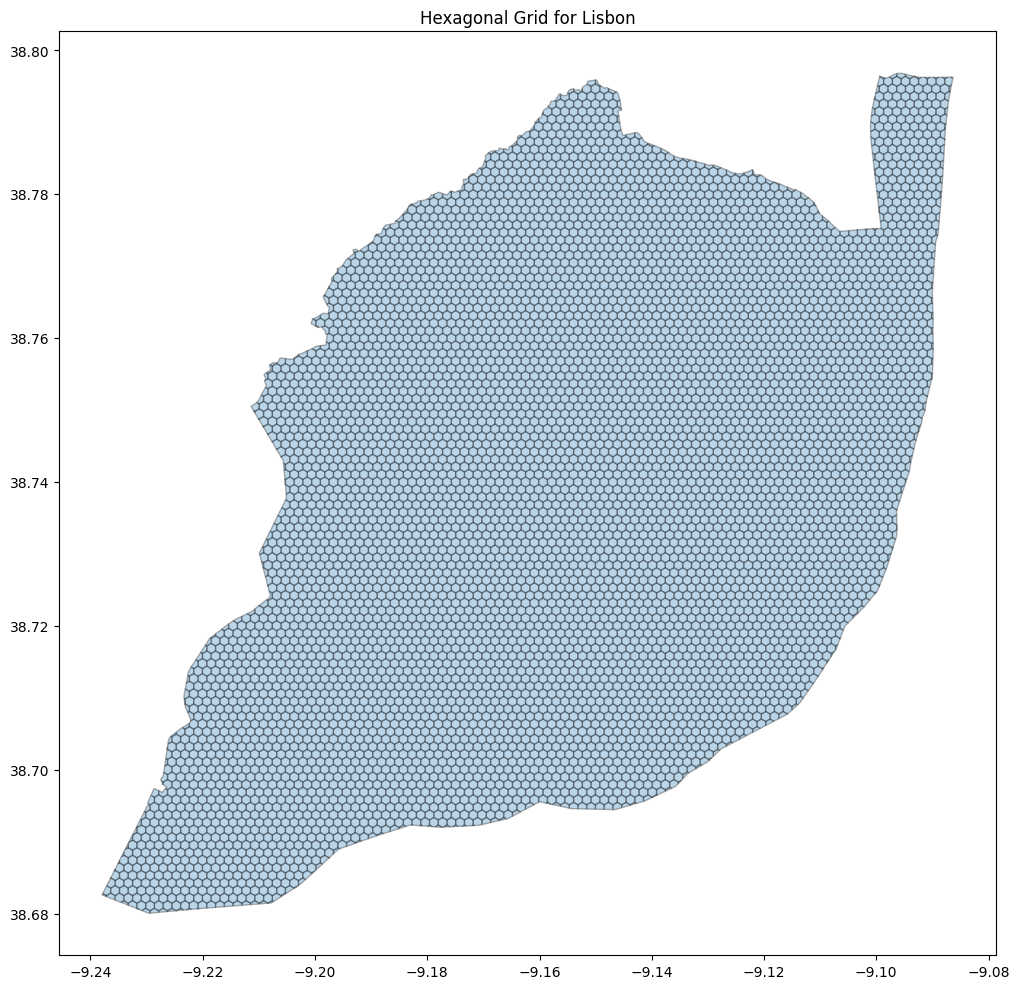

In [8]:
# Plot the hexagonal grid to visualize coverage
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
hex_grid.plot(ax=ax, alpha=0.3, edgecolor='black')
plt.title(f'Hexagonal Grid for {city}')
plt.tight_layout()
plt.show()

## 4. Map Zones to Hexagons

We'll map each mitigation zone to the nearest hexagon in the grid by:
1. Creating Point geometries for each mitigation zone based on lat/lon
2. Finding the nearest hexagon for each point

In [ ]:
# Define CRS
wgs84_crs = "EPSG:4326"  # WGS84 for geometry queries
portugal_metric_crs = "EPSG:3763"  # ETRS89 / Portugal TM06 for area calculations

# Convert the clean zones DataFrame to a GeoDataFrame with Point geometry
geometry = [Point(lon, lat) for lon, lat in zip(clean_zones['lon'], clean_zones['lat'])]
zones_gdf = gpd.GeoDataFrame(clean_zones, geometry=geometry, crs=wgs84_crs)

# Ensure both GeoDataFrames have the same CRS
hex_grid = hex_grid.to_crs(wgs84_crs)

# Function to find the nearest hexagon for each point
def find_nearest_hexagon(point, hexagons):
    distances = [point.distance(hexagon) for hexagon in hexagons.geometry]
    nearest_idx = np.argmin(distances)
    return hexagons.iloc[nearest_idx]

# Map each mitigation zone to the nearest hexagon
mapped_hexagons = []

# Use tqdm to show progress while mapping zones to hexagons
for idx, point in tqdm(enumerate(zones_gdf.geometry), 
                       total=len(zones_gdf.geometry),
                       desc="Mapping zones to hexagons"):
    nearest_hex = find_nearest_hexagon(point, hex_grid)
    # Create a dictionary with mitigation zone properties and hexagon geometry
    hex_mapping = {
        "zone_id": zones_gdf.iloc[idx]["zone_id"],
        "original_lat": zones_gdf.iloc[idx]["lat"],
        "original_lon": zones_gdf.iloc[idx]["lon"],
        f"{type}_value": zones_gdf.iloc[idx]["risk"],
        # 'risk': zones_gdf.iloc[idx]['risk'],
        f"{type}_level": zones_gdf.iloc[idx]["RL"],
        # "risk_level": zones_gdf.iloc[idx]["RL"],
        "hex_id": nearest_hex["hex_id"],
        "hex_geometry": nearest_hex.geometry,
    }
    mapped_hexagons.append(hex_mapping)

# Create a new GeoDataFrame with the mapped hexagons
mitigation_hexagons = gpd.GeoDataFrame(
    mapped_hexagons, geometry="hex_geometry", crs=wgs84_crs
)
mitigation_hexagons.head()

Mapping zones to hexagons:   0%|          | 0/9905 [00:00<?, ?it/s]

,zone_id,original_lat,original_lon,mitigation_intense_value,mitigation_intense_level,hex_id,hex_geometry
0,0,38.68056,-9.230507,0.832176,3,h_5,"POLYGON ((-9.23016 38.68073, -9.22939 38.68038..."
1,1,38.68056,-9.229348,0.826347,3,h_104,"POLYGON ((-9.22861 38.68073, -9.22939 38.68038..."
2,2,38.68056,-9.228190,0.824645,3,h_105,"POLYGON ((-9.22705 38.68073, -9.22783 38.68038..."
3,3,38.68056,-9.227031,0.826520,3,h_7,"POLYGON ((-9.22783 38.68038, -9.22705 38.68073..."
4,4,38.68056,-9.225872,0.831354,3,h_8,"POLYGON ((-9.22627 38.68038, -9.2255 38.68073,..."


In [10]:
# Check for duplicate hexagons (multiple mitigation zones mapped to the same hexagon)
duplicate_hexagons = mitigation_hexagons['hex_id'].value_counts()
print(f"Number of unique hexagons: {len(duplicate_hexagons)}")
print(f"Number of hexagons with multiple mappings: {sum(duplicate_hexagons > 1)}")

# Show top hexagons with multiple mappings
if sum(duplicate_hexagons > 1) > 0:
    print("\nTop hexagons with multiple mappings:")
    print(duplicate_hexagons[duplicate_hexagons > 1].head(10))

Number of unique hexagons: 6407
Number of hexagons with multiple mappings: 3498

Top hexagons with multiple mappings:
hex_id
h_5484    2
h_4388    2
h_4365    2
h_4367    2
h_4368    2
h_4370    2
h_4371    2
h_4373    2
h_4376    2
h_4379    2
Name: count, dtype: int64


## 5. Visualize the Mapped Mitigation Zones

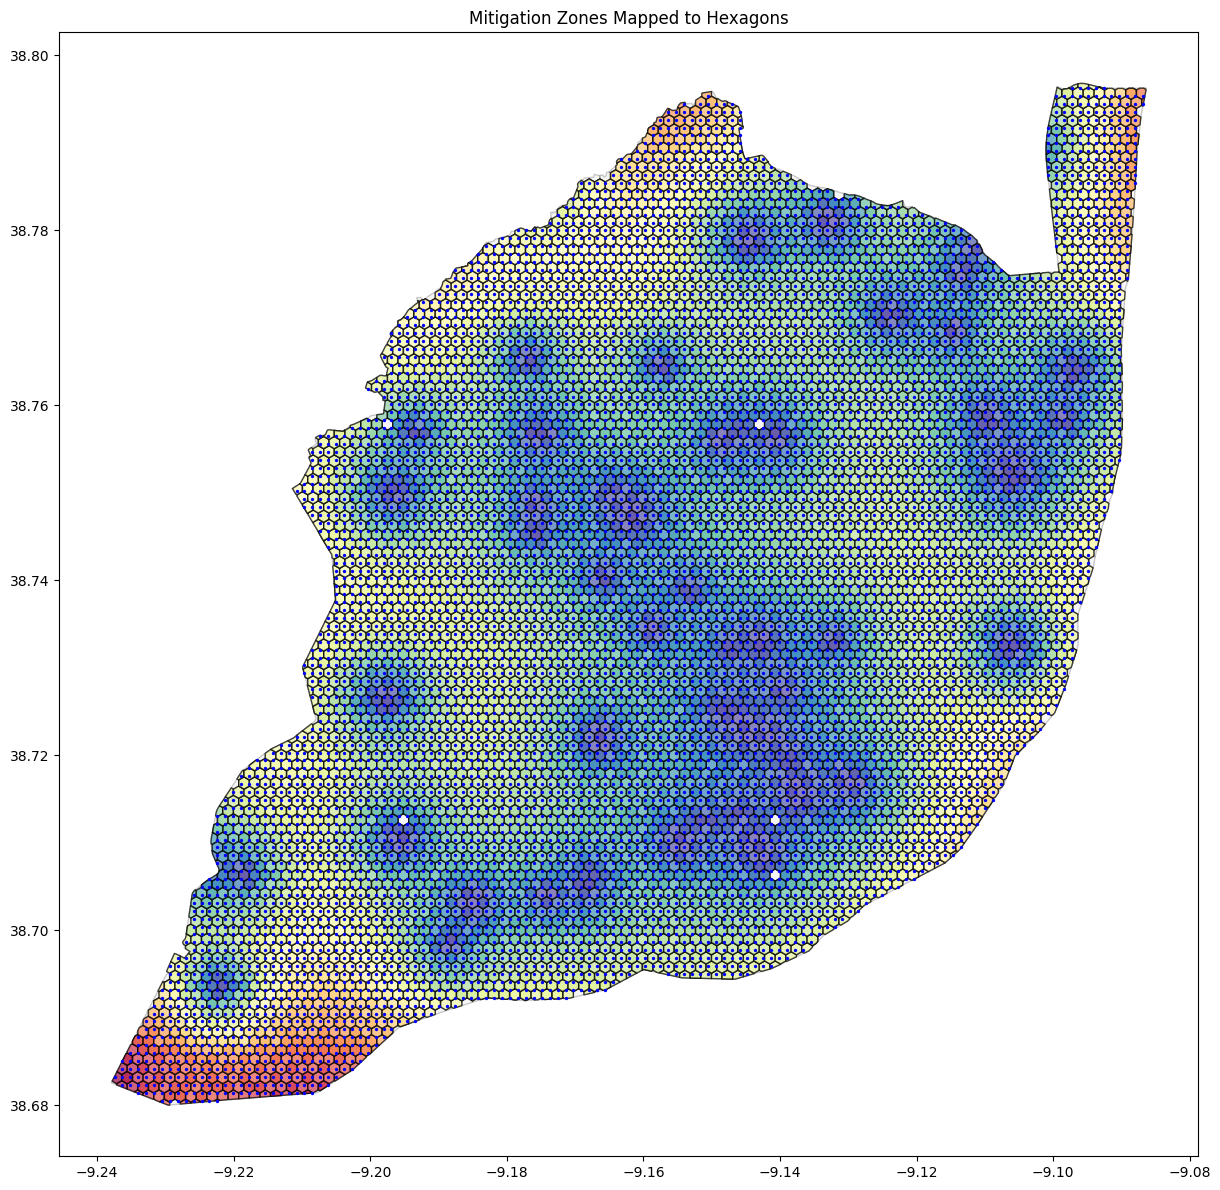

In [11]:
# Visualize the original points and the mapped hexagons
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hex_grid.plot(ax=ax, alpha=0.2, edgecolor='black', color='lightgray')
mitigation_hexagons.plot(
    ax=ax,
    alpha=0.7,
    edgecolor="black",
    column=f"{type}_value",
    cmap="Spectral_r",
    legend=False,
)
zones_gdf.plot(ax=ax, color='blue', markersize=2)
plt.title('Mitigation Zones Mapped to Hexagons')
plt.tight_layout()
plt.show()

## 6. Handle Duplicate Mappings

When multiple mitigation zones map to the same hexagon, we need a strategy to combine their attributes. We'll use:
- Maximum risk value
- Sum of other numeric values
- Logical OR for boolean values

In [ ]:
# Group by hex_id and aggregate
# For risk columns: take the maximum value (conservative approach)
# For boolean columns: use logical OR (True if any is True)
# For other numeric columns: sum them

aggregation = {
    f"{type}_value": "max",
    f"{type}_level": "max",
    "hex_geometry": "first",
}

merged_hexagons = mitigation_hexagons.groupby('hex_id').agg(aggregation).reset_index()
merged_hexagons = gpd.GeoDataFrame(
    merged_hexagons, geometry="hex_geometry", crs=wgs84_crs
)

# Normalize merged hexagons


print(f"Number of hexagons after merging: {len(merged_hexagons)}")

# Normalize the value column to a 0-1 scale
merged_hexagons[f"{type}_value"] = (merged_hexagons[f"{type}_value"] - merged_hexagons[f"{type}_value"].min()) / (merged_hexagons[f"{type}_value"].max() - merged_hexagons[f"{type}_value"].min())

mitigation_hexagons.describe()

Number of hexagons after merging: 6407


,zone_id,original_lat,original_lon,mitigation_intense_value,mitigation_intense_level
count,9905.000000,9905.000000,9905.000000,9905.000000,9905.000000
mean,4952.000000,38.737678,-9.156780,0.277884,2.032004
std,2859.471542,0.027953,0.035548,0.169137,0.675923
min,0.000000,38.680560,-9.237460,0.000000,1.000000
25%,2476.000000,38.714900,-9.185314,0.152116,2.000000
50%,4952.000000,38.738396,-9.156344,0.261433,2.000000
75%,7428.000000,38.760989,-9.128533,0.365153,2.000000
max,9904.000000,38.796233,-9.086816,1.000000,3.000000


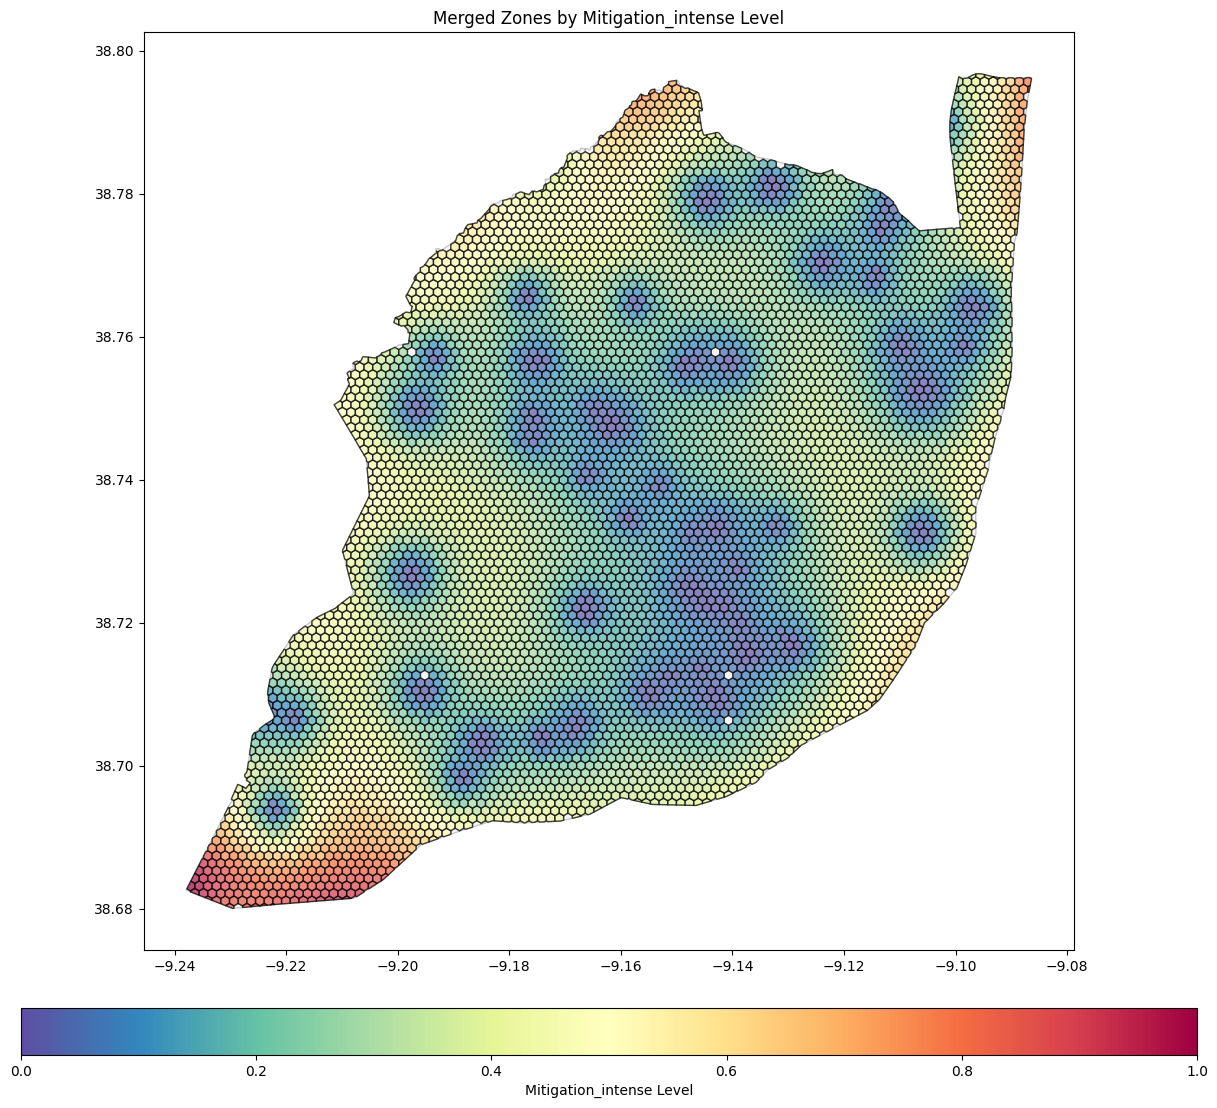

In [13]:
# Visualize the merged hexagons by risk level
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hex_grid.plot(ax=ax, alpha=0.2, edgecolor="black", color="lightgray")
merged_hexagons.plot(
    ax=ax,
    alpha=0.7,
    edgecolor="black",
    column=f"{type}_value",
    cmap="Spectral_r",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.8,
        "aspect": 25,
        "pad": 0.05,
        "label": f"{type.capitalize()} Level",
    },
)
plt.title(f"Merged Zones by {type.capitalize()} Level")
plt.tight_layout()
plt.show()

## 7. Finalize and Save the Hexagonal Mitigation Zones

Format the output to be compatible with VERUS spatiotemporal assessment.

In [14]:
# Rename the columns to match VERUS output format where applicable
final_hexagons = merged_hexagons.rename(
    columns={f"{type}_value": "value", f"{type}_level": "level"}
)

# Reorder columns for clarity
column_order = ["hex_id", "value", "level"]
final_hexagons = final_hexagons[column_order + [col for col in final_hexagons.columns if col not in column_order]]

final_hexagons["value"].describe()

count    6407.000000
mean        0.285321
std         0.170656
min         0.000000
25%         0.159783
50%         0.266995
75%         0.371615
max         1.000000
Name: value, dtype: float64

## 8. Compare with VERUS Vulnerability Zones

Let's compare our mitigation zones with the VERUS vulnerability zones to ensure compatibility.

In [15]:
# Load a VERUS vulnerability assessment output file
vuln_zones_path = f"../data/vulnerability_layer/{city.lower()}/{city}_vulnerability_zones_s1.geojson"
vulnerability_zones = gpd.read_file(vuln_zones_path)

print(f"Number of vulnerability zones: {len(vulnerability_zones)}")
print(f"Number of mitigation zones: {len(final_hexagons)}")

# Check if the hexagon IDs are compatible
vuln_hex_ids = set(vulnerability_zones['hex_id'])
mitigation_hex_ids = set(final_hexagons['hex_id'])

# Find the intersection
common_hex_ids = vuln_hex_ids.intersection(mitigation_hex_ids)
print(f"Number of common hexagon IDs: {len(common_hex_ids)}")

# Calculate coverage
coverage_percent_vuln = len(common_hex_ids) / len(vuln_hex_ids) * 100
coverage_percent_mitigation = len(common_hex_ids) / len(mitigation_hex_ids) * 100

print(f"Coverage of vulnerability zones by mitigation zones: {coverage_percent_vuln:.2f}%")
print(f"Coverage of mitigation zones by vulnerability zones: {coverage_percent_mitigation:.2f}%")

Number of vulnerability zones: 6569
Number of mitigation zones: 6407
Number of common hexagon IDs: 6407
Coverage of vulnerability zones by mitigation zones: 97.53%
Coverage of mitigation zones by vulnerability zones: 100.00%


## 9. Identify and Fill Blind Spots

As we can see in our visualization, there are some hexagons in the grid that weren't mapped to any mitigation zone, creating "blind spots" in our coverage. Let's identify these blind spots and fill them by interpolating values from neighboring hexagons.

Number of hexagons in the grid: 6569
Number of mapped hexagons: 6407
Number of blind spots: 162


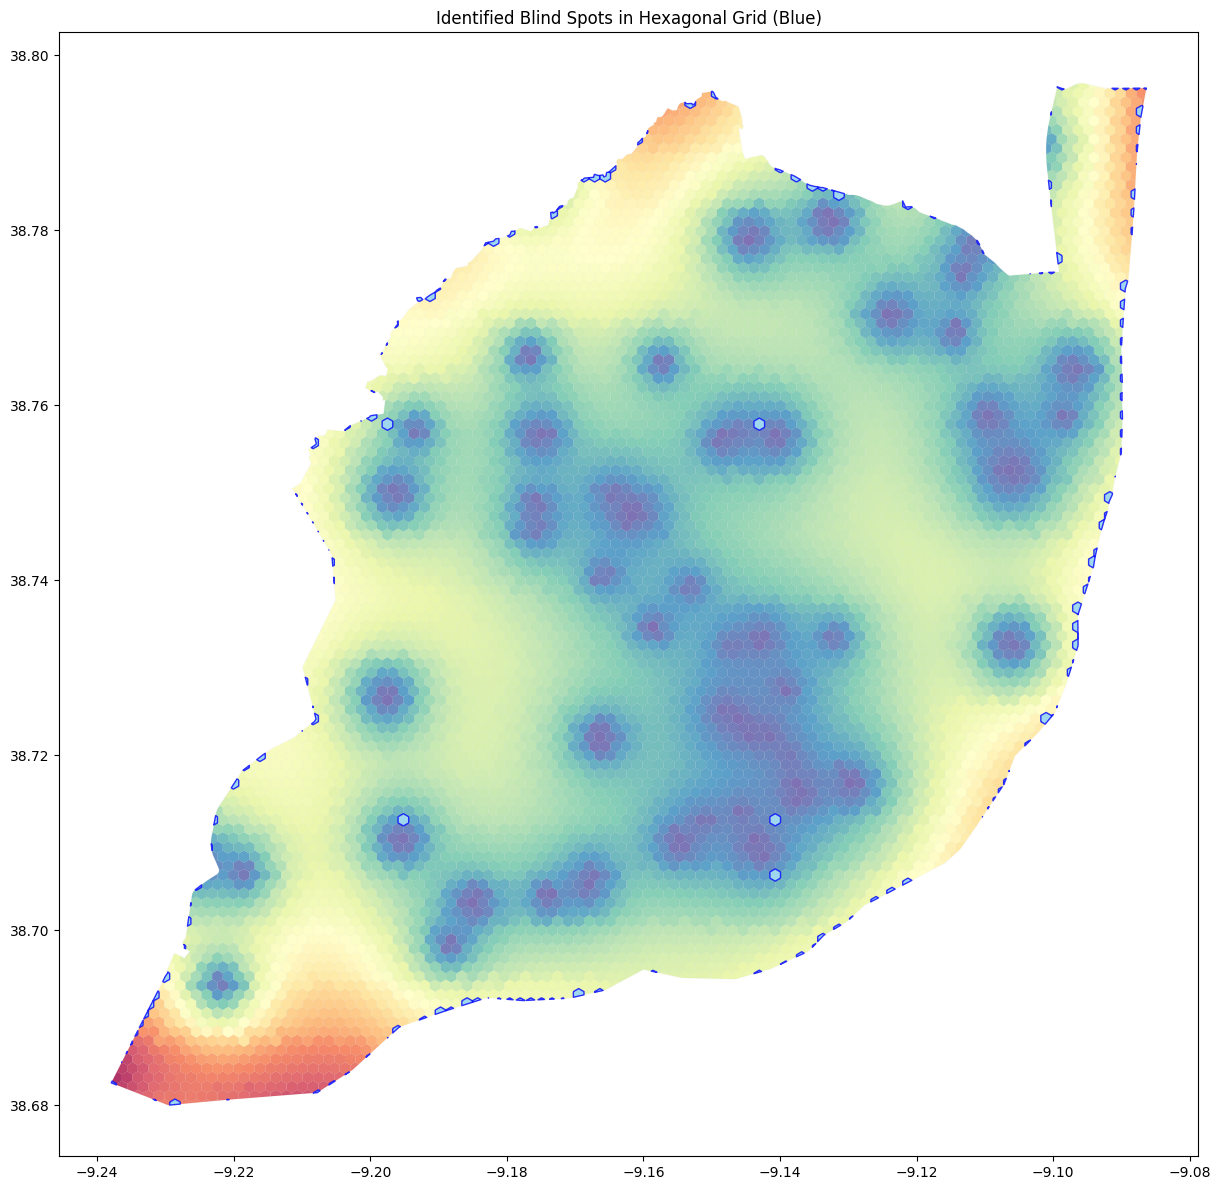

In [16]:
# Identify hexagons in the grid that aren't in our mitigation zones
all_hex_ids = set(hex_grid['hex_id'])
mapped_hex_ids = set(final_hexagons['hex_id'])
blind_spot_ids = all_hex_ids - mapped_hex_ids

print(f"Number of hexagons in the grid: {len(all_hex_ids)}")
print(f"Number of mapped hexagons: {len(mapped_hex_ids)}")
print(f"Number of blind spots: {len(blind_spot_ids)}")

# Filter the hexagon grid to get only the blind spots
blind_spots = hex_grid[hex_grid['hex_id'].isin(blind_spot_ids)].copy()

# Visualize the blind spots
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hex_grid.plot(ax=ax, alpha=0.1, edgecolor='lightgray', color='white')
final_hexagons.plot(ax=ax, alpha=0.8, column='value', cmap='Spectral_r')
blind_spots.plot(ax=ax, alpha=0.8, color='skyblue', edgecolor='blue')
plt.title('Identified Blind Spots in Hexagonal Grid (Blue)')
plt.tight_layout()
plt.show()

In [17]:
# Fill blind spots by interpolating values from neighboring hexagons
# We'll use a spatial join to find the closest hexagons and interpolate values

def fill_blind_spots(hex_grid, final_hexagons, blind_spot_ids):
    # Determine which geometry column to use
    geom_col = final_hexagons._geometry_column_name
    
    # Create a copy of the hex grid to work with
    filled_hexagons = final_hexagons.copy()
    
    # Get the blind spots from the hex grid
    blind_spots = hex_grid[hex_grid['hex_id'].isin(blind_spot_ids)].copy()
    
    # Create a list to store all the new rows
    new_rows = []
    
    # For each blind spot, find the nearest N mapped hexagons and interpolate values
    for idx, blind_spot in blind_spots.iterrows():
        # Calculate distances to all mapped hexagons
        distances = [blind_spot.geometry.centroid.distance(hex_geom.centroid) 
                    for hex_geom in final_hexagons.geometry]
        
        # Get the nearest 5 hexagons (or fewer if there are less than 5)
        n_nearest = min(5, len(distances))
        nearest_indices = np.argsort(distances)[:n_nearest]
        nearest_hexagons = final_hexagons.iloc[nearest_indices]
        
        # Calculate weights based on inverse distance
        weights = 1.0 / np.array([distances[i] for i in nearest_indices])
        weights = weights / weights.sum()  # Normalize weights
        
        # Interpolate numeric values using inverse distance weighting
        value = sum(nearest_hexagons['value'] * weights)
        
        # For categorical values, use the mode or most frequent value
        level = nearest_hexagons['level'].mode()[0]

        
        # Determine color based on the value range
        color = pd.cut([value], bins=[0, 0.1, 0.2, 0.3, 0.4, 1], 
                      labels=['#ffeda0', '#feb24c', '#fc9272', '#de2d26', '#bd0026'])[0]
        
        # Create a new row for this filled hexagon with the right geometry column name
        new_hex_data = {
            'hex_id': blind_spot['hex_id'],
            'value': value,
            'level': level,
            'color': color,
            geom_col: blind_spot.geometry
        }
        
        # Add the new data to our list of rows
        new_rows.append(new_hex_data)
    
    # If we have new rows to add, create a DataFrame all at once and concatenate
    if new_rows:
        # Create a new DataFrame with all the new rows at once
        new_df = pd.DataFrame(new_rows)
        
        # Ensure the dtypes match before concatenation
        for col in new_df.columns:
            if col in filled_hexagons.columns and col != geom_col:
                new_df[col] = new_df[col].astype(filled_hexagons[col].dtype)
        
        # Add all the new rows to filled_hexagons at once
        filled_hexagons = pd.concat([filled_hexagons, new_df], ignore_index=True)
    
    return gpd.GeoDataFrame(filled_hexagons, geometry=geom_col, crs="EPSG:4326")

# Call the function to fill blind spots
filled_hexagons = fill_blind_spots(hex_grid, final_hexagons, blind_spot_ids)

print(f"Number of hexagons after filling blind spots: {len(filled_hexagons)}")
print(f"Coverage of the hexagon grid: {len(filled_hexagons) / len(hex_grid) * 100:.2f}%")

Number of hexagons after filling blind spots: 6569
Coverage of the hexagon grid: 100.00%


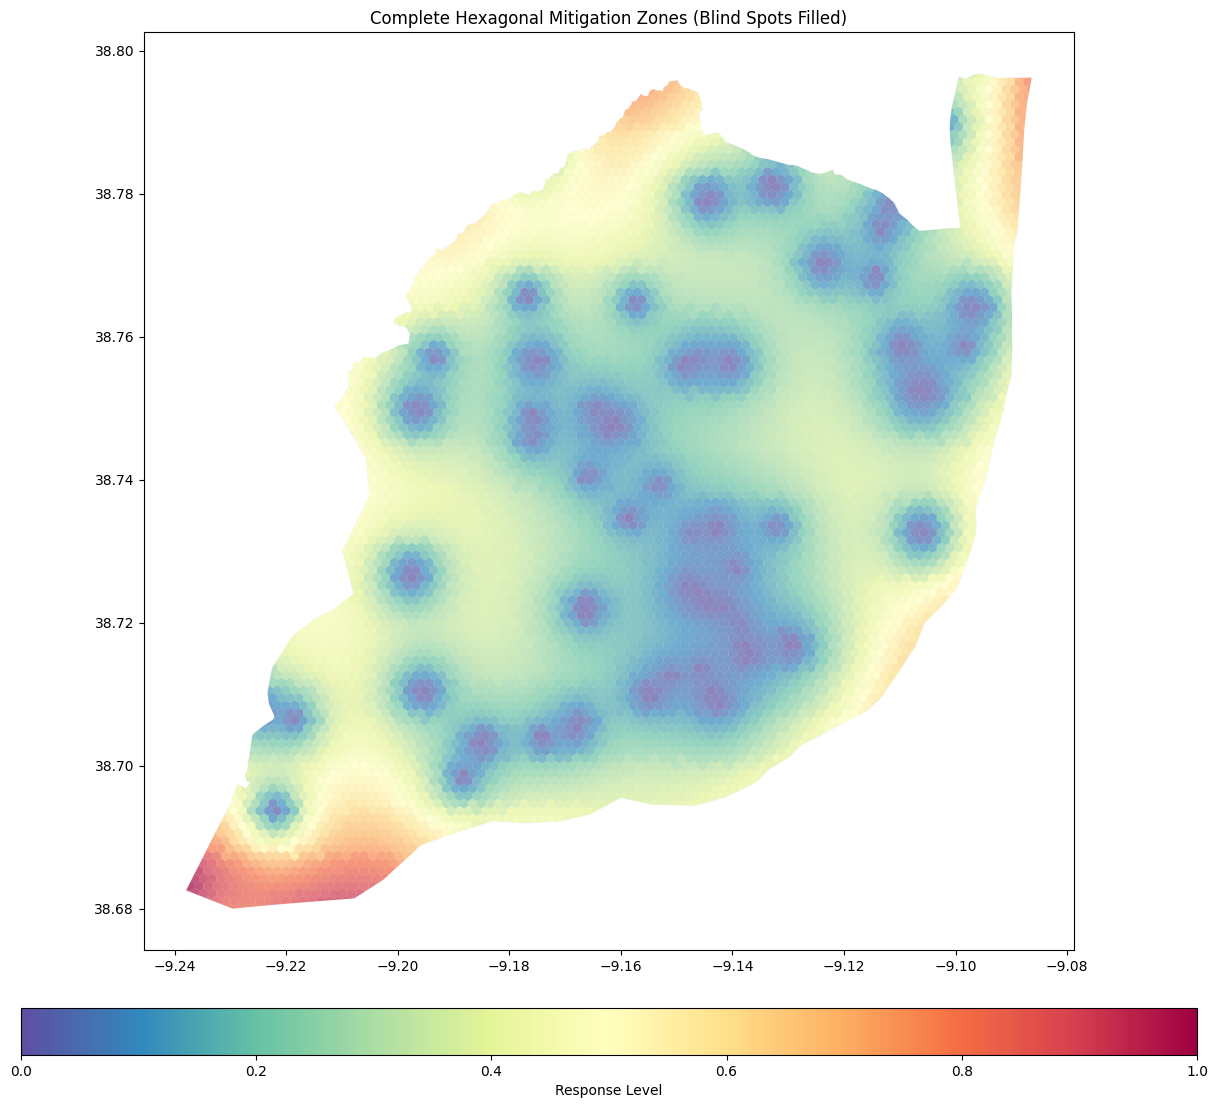

In [18]:
# Visualize the filled hexagons
fig, ax = plt.subplots(1, 1, figsize=(15, 12))
hex_grid.plot(ax=ax, alpha=0.1, edgecolor='lightgray', color='white')
filled_hexagons.plot(
    ax=ax,
    alpha=0.7,
    column="value",
    cmap="Spectral_r",
    legend=True,
    legend_kwds={
        "orientation": "horizontal",
        "shrink": 0.8,
        "aspect": 25,
        "pad": 0.05,
        "label": "Response Level",
    },
)
plt.title('Complete Hexagonal Mitigation Zones (Blind Spots Filled)')
plt.tight_layout()
plt.show()

In [19]:
# Save the filled hexagonal mitigation zones
# filled_output_path = f"../data/response_layer/{city}_mitigation_zones.geojson"
filled_output_path = f"../data/{layer}/{city}_{type}_zones.geojson"

# Save to GeoJSON
filled_hexagons.to_file(filled_output_path, driver="GeoJSON")
print(f"Saved filled hexagonal mitigation zones to {filled_output_path}")

Saved filled hexagonal mitigation zones to ../data/response_layer/Lisbon_mitigation_intense_zones.geojson


In [20]:
# Add this after each major transformation step:

# After loading original data
print("Original data distribution:")
print(mitigation_zones["risk"].describe())

# After aggregation
print("\nAfter aggregation (max values):")
print(merged_hexagons[f"{type}_value"].describe())

# After normalization
print("\nAfter normalization:")
print(merged_hexagons[f"{type}_value"].describe())

# After filling blind spots
print("\nAfter filling blind spots:")
print(filled_hexagons["value"].describe())

Original data distribution:
count    9905.000000
mean        0.277884
std         0.169137
min         0.000000
25%         0.152116
50%         0.261433
75%         0.365153
max         1.000000
Name: risk, dtype: float64

After aggregation (max values):
count    6407.000000
mean        0.285321
std         0.170656
min         0.000000
25%         0.159783
50%         0.266995
75%         0.371615
max         1.000000
Name: mitigation_intense_value, dtype: float64

After normalization:
count    6407.000000
mean        0.285321
std         0.170656
min         0.000000
25%         0.159783
50%         0.266995
75%         0.371615
max         1.000000
Name: mitigation_intense_value, dtype: float64

After filling blind spots:
count    6569.000000
mean        0.289904
std         0.173595
min         0.000000
25%         0.161811
50%         0.271615
75%         0.380285
max         1.000000
Name: value, dtype: float64
